In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

X, y = make_regression(
    n_samples=500,
    n_features=10,
    n_informative=5,
    noise=15,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [2]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


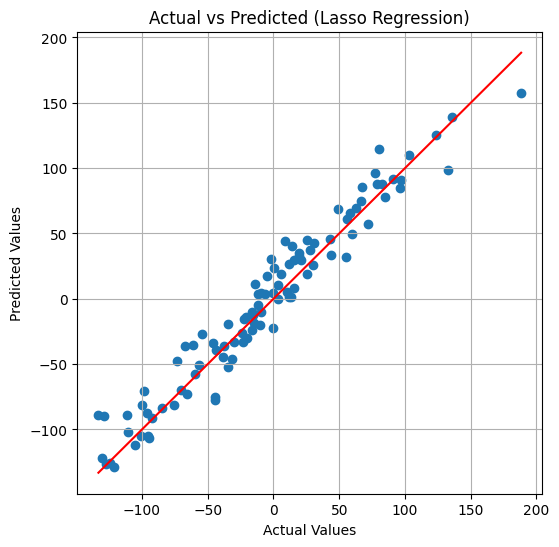

In [3]:
y_pred = lasso.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

y_pred = lasso.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Lasso Regression)")
plt.grid(True)
plt.show()

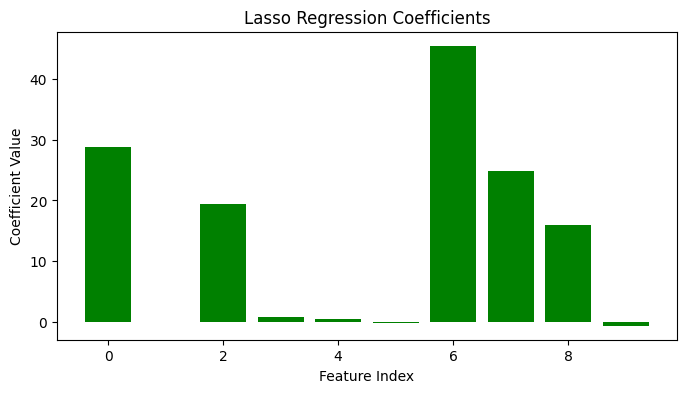

In [4]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(lasso.coef_)), lasso.coef_, color="green")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regression Coefficients")
plt.show()

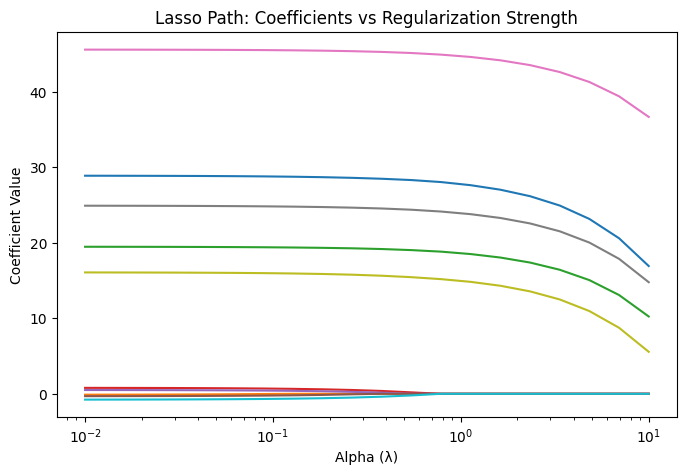

In [5]:
alphas = np.logspace(-2, 1, 20)
coefficients = []

for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_train, y_train)
    coefficients.append(model.coef_)

coefficients = np.array(coefficients)

plt.figure(figsize=(8, 5))
for i in range(coefficients.shape[1]):
    plt.plot(alphas, coefficients[:, i])
plt.xscale("log")
plt.xlabel("Alpha (λ)")
plt.ylabel("Coefficient Value")
plt.title("Lasso Path: Coefficients vs Regularization Strength")
plt.show()

In [10]:
# YOUR TURN! Implement LASSO regression from scratch

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [11]:
class LassoRegression():
    def __init__(self, learning_rate, iterations, l1_penalty):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.l1_penalty = l1_penalty

    def fit(self, X, Y):
        self.m, self.n = X.shape
        self.W = np.zeros(self.n)
        self.b = 0
        self.X = X
        self.Y = Y

        for i in range(self.iterations):
            self.update_weights()
        return self

    def update_weights(self):
        Y_pred = self.predict(self.X)
      
        dW = np.zeros(self.n)
        for j in range(self.n):
            if self.W[j] > 0:
                dW[j] = (-2 * (self.X[:, j]).dot(self.Y - Y_pred) +
                         self.l1_penalty) / self.m
            else:
                dW[j] = (-2 * (self.X[:, j]).dot(self.Y - Y_pred) -
                         self.l1_penalty) / self.m

        db = -2 * np.sum(self.Y - Y_pred) / self.m

        self.W = self.W - self.learning_rate * dW
        self.b = self.b - self.learning_rate * db
        return self

    def predict(self, X):
        return X.dot(self.W) + self.b

In [15]:
df = pd.read_csv(r'C:\Users\Troy\Downloads\sci-ml\datasets\Experience-Salary.csv')
df.head(10)

,Years of Experience,Salary
0,4.941931,9372.711912
1,9.069024,23015.300694
2,8.109230,17039.178915
3,9.807933,19905.398181
4,6.274945,17033.827082
5,12.148903,24040.853172
6,17.413257,41059.757801
7,3.233105,14506.173074
8,10.830203,22462.243836
9,3.509294,5177.362564


In [17]:
X = df.iloc[:, :-1].values
Y = df.iloc[:, 1].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=1/3, random_state=0)

model = LassoRegression(iterations=1000, learning_rate=0.01, l1_penalty=500)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
print("Predicted values: ", np.round(Y_pred[:3], 2))
print("Real values:      ", Y_test[:3])
print("Trained W:        ", round(model.W[0], 2))
print("Trained b:        ", round(model.b, 2))

Predicted values:  [35539.41 18099.76 43796.5 ]
Real values:       [42328.57198221 16443.83637617 44375.48684823]
Trained W:         11516.31
Trained b:         26129.99


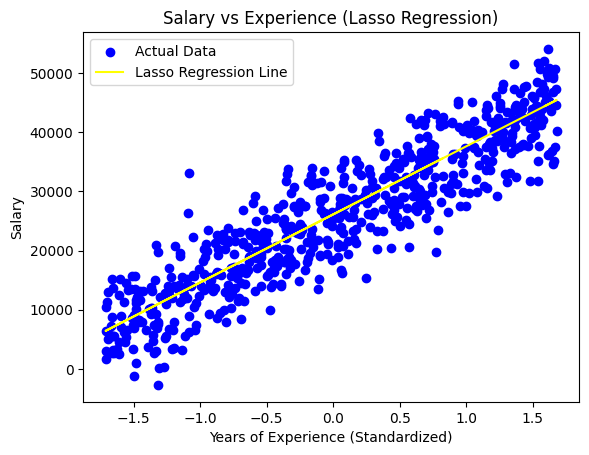

In [18]:
plt.scatter(X_test, Y_test, color='blue', label='Actual Data')
plt.plot(X_test, Y_pred, color='yellow', label='Lasso Regression Line')
plt.title('Salary vs Experience (Lasso Regression)')
plt.xlabel('Years of Experience (Standardized)')
plt.ylabel('Salary')
plt.legend()
plt.show()